In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv(
    "../data/processed/hourly_device_energy_scaled.csv",
    parse_dates=["timestamp"]
)

df = df.set_index("timestamp")
df = df.sort_index()

print(df.head())

              Appliance Type  Energy Consumption (kWh)
timestamp                                             
2023-01-01  Air Conditioning                  0.155360
2023-01-01        Dishwasher                  0.116344
2023-01-01   Washing Machine                  0.039367
2023-01-01            Fridge                  0.028120
2023-01-01         Microwave                  0.059051


In [15]:
# %% ---------------- SEQUENCE CREATION FUNCTION ----------------

def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)



Processing appliance: Lights


C:\Users\cherp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


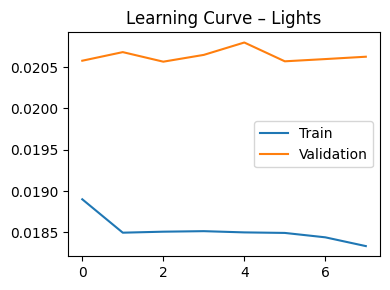


Processing appliance: Fridge


C:\Users\cherp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


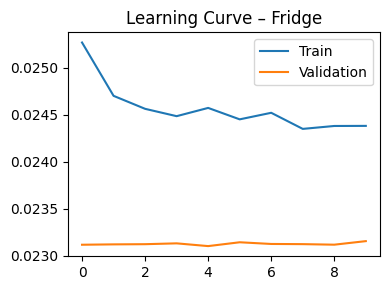


Processing appliance: Dishwasher


C:\Users\cherp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


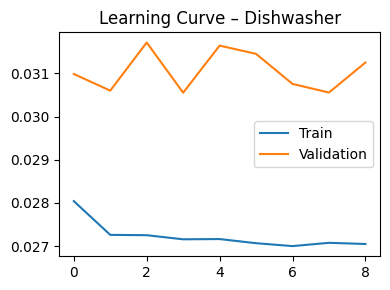


Processing appliance: Air Conditioning


C:\Users\cherp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


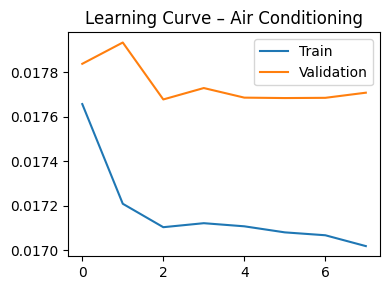


Processing appliance: Microwave


C:\Users\cherp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


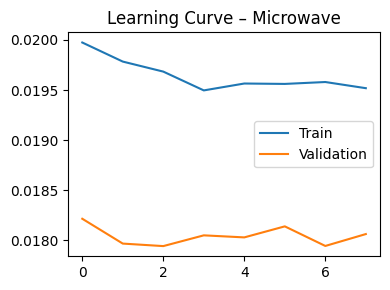


Processing appliance: Washing Machine


C:\Users\cherp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


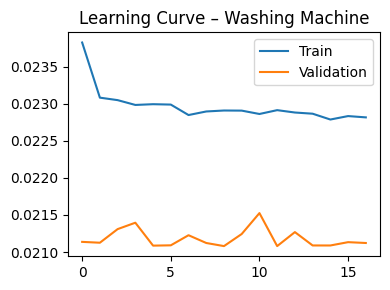


Processing appliance: TV


C:\Users\cherp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


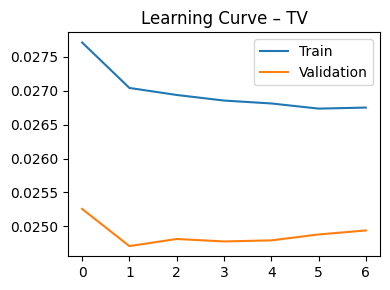


Processing appliance: Computer


C:\Users\cherp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


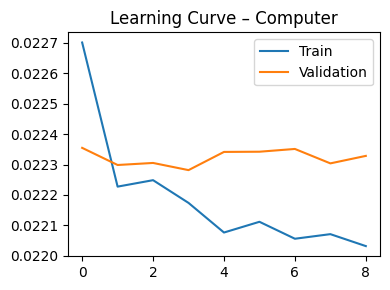


Processing appliance: Heater


C:\Users\cherp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


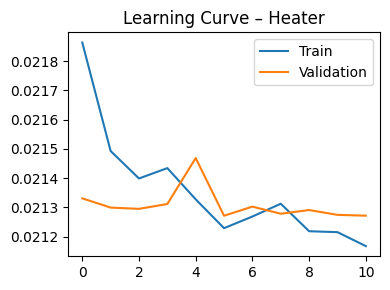


Processing appliance: Oven


C:\Users\cherp\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


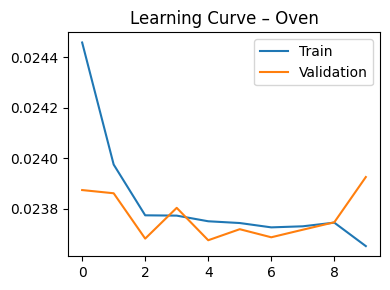

In [20]:
# %% ---------------- MODEL TRAINING LOOP ----------------

results = []
appliances = df["Appliance Type"].unique()

TIME_STEPS = 24

for appliance_name in appliances:

    print(f"\nProcessing appliance: {appliance_name}")

    appliance_df = df[df["Appliance Type"] == appliance_name].copy()
    appliance_df = appliance_df.sort_index()

    # Skip if not enough data
    if len(appliance_df) <= TIME_STEPS + 10:
        print("Not enough data, skipping...")
        continue

    # ---------------- SCALING ----------------
    scaler = MinMaxScaler(feature_range=(0, 1))
    energy_scaled = scaler.fit_transform(
        appliance_df[['Energy Consumption (kWh)']]
    )

    # ---------------- CREATE SEQUENCES ----------------
    X, y = create_sequences(energy_scaled, TIME_STEPS)

    # ---------------- TRAIN TEST SPLIT ----------------
    split_index = int(0.8 * len(X))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    # ---------------- RESHAPE FOR LSTM ----------------
    X_train_lstm = X_train.reshape((X_train.shape[0], TIME_STEPS, 1))
    X_test_lstm = X_test.reshape((X_test.shape[0], TIME_STEPS, 1))

    # ---------------- BUILD LSTM ----------------
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error'
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_lstm,
        y_train,
        epochs=30,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    # ---------------- LEARNING CURVE ----------------
    plt.figure(figsize=(4,3))
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Validation")
    plt.title(f"Learning Curve – {appliance_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------- LSTM PREDICTION ----------------
    y_pred_scaled = model.predict(X_test_lstm, verbose=0)

    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_actual = scaler.inverse_transform(y_pred_scaled)

    mae_lstm = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    r2_lstm = r2_score(y_test_actual, y_pred_actual)

    # ---------------- BASELINE LINEAR REGRESSION ----------------
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)

    y_pred_lr_scaled = lr_model.predict(X_test)
    y_pred_lr = scaler.inverse_transform(
        y_pred_lr_scaled.reshape(-1, 1)
    )

    mae_lr = mean_absolute_error(y_test_actual, y_pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test_actual, y_pred_lr))
    r2_lr = r2_score(y_test_actual, y_pred_lr)

    # ---------------- SAVE MODEL ----------------
    model.save(
        f"../models/lstm_energy_model_{appliance_name.replace(' ', '_')}.keras"
    )
    import joblib
    joblib.dump(
        scaler,
        f"../models/scaler_{appliance_name.replace(' ', '_')}.pkl"
    )

    # ---------------- STORE RESULTS ----------------
    results.append({
        "Appliance": appliance_name,
        "LR_MAE": mae_lr,
        "LR_RMSE": rmse_lr,
        "LR_R2": r2_lr,
        "LSTM_MAE": mae_lstm,
        "LSTM_RMSE": rmse_lstm,
        "LSTM_R2": r2_lstm
    })


          Appliance    LR_MAE   LR_RMSE     LR_R2  LSTM_MAE  LSTM_RMSE  \
1            Fridge  0.009882  0.012233 -0.003961  0.009854   0.012209   
0            Lights  0.035966  0.043801 -0.006631  0.035928   0.043711   
5   Washing Machine  0.035725  0.043818 -0.004412  0.035577   0.043738   
6                TV  0.036120  0.044567 -0.005146  0.036009   0.044470   
7          Computer  0.035793  0.044730 -0.005811  0.035906   0.044621   
4         Microwave  0.036819  0.046121 -0.003907  0.036613   0.046050   
9              Oven  0.036890  0.046246 -0.005221  0.036893   0.046152   
2        Dishwasher  0.037549  0.046930 -0.004165  0.038674   0.047310   
8            Heater  0.098233  0.123861 -0.003672  0.098006   0.123770   
3  Air Conditioning  0.102843  0.130012 -0.003707  0.102551   0.129878   

    LSTM_R2         Best_Model  
1 -0.000049               LSTM  
0 -0.002483               LSTM  
5 -0.000766               LSTM  
6 -0.000754               LSTM  
7 -0.000901         

<Figure size 1000x600 with 0 Axes>

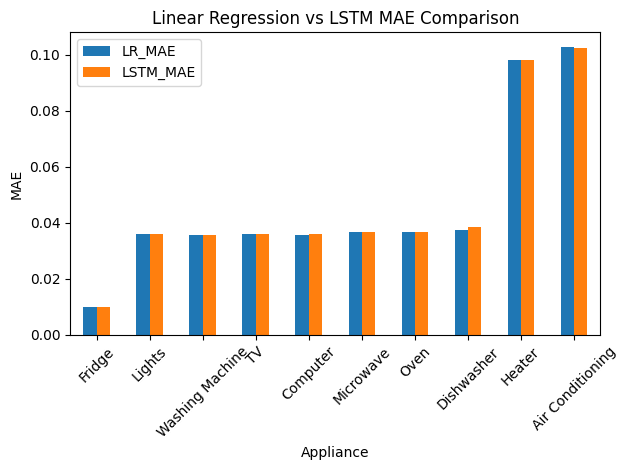

<Figure size 1000x600 with 0 Axes>

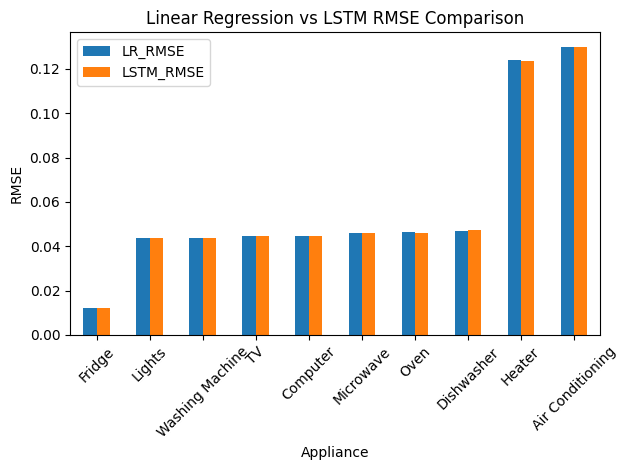

<Figure size 1000x600 with 0 Axes>

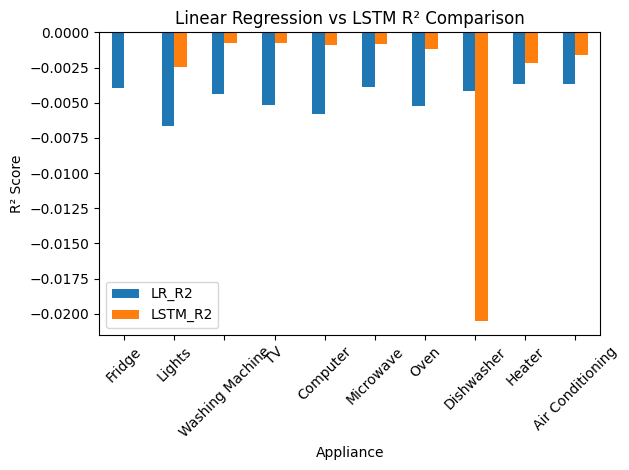

In [17]:
# %% ---------------- RESULTS ANALYSIS ----------------

results_df = pd.DataFrame(results)

results_df["Best_Model"] = np.where(
    results_df["LSTM_RMSE"] < results_df["LR_RMSE"],
    "LSTM",
    "Linear Regression"
)

results_df = results_df.sort_values("LSTM_RMSE")

print(results_df)

# Save results
import os
os.makedirs("../outputs", exist_ok=True)
results_df.to_csv("../outputs/module5_model_comparison.csv", index=False)

# ---------------- MAE ----------------
plt.figure(figsize=(10,6))
results_df.set_index("Appliance")[["LR_MAE","LSTM_MAE"]].plot(kind="bar")
plt.title("Linear Regression vs LSTM MAE Comparison")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------- RMSE ----------------
plt.figure(figsize=(10,6))
results_df.set_index("Appliance")[["LR_RMSE","LSTM_RMSE"]].plot(kind="bar")
plt.title("Linear Regression vs LSTM RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------- R2 ----------------
plt.figure(figsize=(10,6))
results_df.set_index("Appliance")[["LR_R2","LSTM_R2"]].plot(kind="bar")
plt.title("Linear Regression vs LSTM R² Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
results_df.round(4)

,Appliance,LR_MAE,LR_RMSE,LR_R2,LSTM_MAE,LSTM_RMSE,LSTM_R2,Best_Model
1,Fridge,0.0099,0.0122,-0.0040,0.0099,0.0122,-0.0000,LSTM
0,Lights,0.0360,0.0438,-0.0066,0.0359,0.0437,-0.0025,LSTM
5,Washing Machine,0.0357,0.0438,-0.0044,0.0356,0.0437,-0.0008,LSTM
6,TV,0.0361,0.0446,-0.0051,0.0360,0.0445,-0.0008,LSTM
7,Computer,0.0358,0.0447,-0.0058,0.0359,0.0446,-0.0009,LSTM
4,Microwave,0.0368,0.0461,-0.0039,0.0366,0.0461,-0.0008,LSTM
9,Oven,0.0369,0.0462,-0.0052,0.0369,0.0462,-0.0012,LSTM
2,Dishwasher,0.0375,0.0469,-0.0042,0.0387,0.0473,-0.0205,Linear Regression
8,Heater,0.0982,0.1239,-0.0037,0.0980,0.1238,-0.0022,LSTM
3,Air Conditioning,0.1028,0.1300,-0.0037,0.1026,0.1299,-0.0016,LSTM


In [19]:
print("\nModel Performance Summary:")
print("----------------------------------")
print("Average LSTM MAE:", results_df["LSTM_MAE"].mean())
print("Average LR MAE:", results_df["LR_MAE"].mean())
print("----------------------------------")



Model Performance Summary:
----------------------------------
Average LSTM MAE: 0.046601127834563626
Average LR MAE: 0.046582155063988405
----------------------------------
